In [1]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import h5py
import os
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

In [2]:
# Setup plot styles for saving figures.
def figure_style():
    global plotStyles,stepStyles
    matplotlib.rcParams.update({"axes.formatter.limits": (-4,4), "svg.fonttype" : "none", 'pdf.fonttype':42,'font.family':'sans-serif','font.sans-serif':'Helvetica','font.size': 9, "axes.titlesize": 10, "xtick.labelsize": 8, "ytick.labelsize": 8,'text.usetex':True,'text.latex.preamble':[r'\usepackage{sansmath}',r'\sansmath']})
    plotStyles={"markersize":4,"markeredgewidth":1.0,"linewidth":1.0}
    stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}

In [3]:
# Setup plot styles for on-screen plotting.
def screen_style(fontSize=20):
    global plotStyles,stepStyles
    matplotlib.rcParams.update({"axes.formatter.limits": (-4,4), "svg.fonttype" : "none", 'pdf.fonttype':42,'font.family':'sans-serif','font.sans-serif':'Helvetica','font.size': fontSize, "axes.titlesize": fontSize, "xtick.labelsize": fontSize, "ytick.labelsize": fontSize,'text.usetex':True,'text.latex.preamble':[r'\usepackage{sansmath}',r'\sansmath']})
    plotStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0}
    stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}

In [4]:
%%javascript
IPython.OutputArea.auto_scroll_threshold = 9999;

<IPython.core.display.Javascript object>

### Execute with time limit.

In [41]:
%%bash
dirname=data/1
filename=${dirname}/microenv_diffusion.lm
sfilename=${dirname}/microenv_diffusion.sfile
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} microenv_diffusion.sbml
lm_setp ${filename} writeInterval=1e-2 maxTime=1e2
rm -f ${sfilename}
echo "Execute the following command in `pwd`:"
echo "lmes -me -f ${filename} -gr 0 -c 3 -r 0 -ff sfile -fo ${sfilename}"


lm_sbml_import v2016.05.10 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


2016-05-14 16:29:29) Processing 1 compartments.
2016-05-14 16:29:29) Added compartment (0) V: 1.000000e+00
2016-05-14 16:29:29) Processing 1 species.
2016-05-14 16:29:29) Added species (0) n with initial count: 1000
2016-05-14 16:29:29) Processing 1 reactions.
2016-05-14 16:29:29) Matched kinetic formula in reaction (0)  to FirstOrderPropensity: [1 * n] == [k1 * x1]
2016-05-14 16:29:29) There output file was successfully genereated.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/1/microenv_diffusion.lm:
maxTime=1e2
writeInterval=1e-2
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/microenv_diffusion:
lmes -me -f data/1/microenv_diffus

### Load the concentration time series.

In [42]:
from robertslab import ndarray
from robertslab.sfile import SFile
import lm.io.ConcentrationsTimeSeries_pb2 as cts

# Set the filename.
dirname="data/1"
filename="%s/microenv_diffusion.sfile"%dirname

# Open the file.

# Get the grid size and count the entries.
numberRecords=0
gridShape=None
file=SFile.fromFilename(filename, "r")
while True:
    record=file.readNextRecord()
    if record is None: break
    if record.name == "/Simulations/0/ConcentrationsTimeSeries":
        obj=cts.ConcentrationsTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        numberRecords += obj.times.shape[0]
        if gridShape is None:
            gridShape = tuple(obj.concentrations[0].shape)
    else:
        file.skipData(record.dataSize)
file.close();

# Load the records for this replicate.
index=0
times=np.zeros((numberRecords,), dtype=float)
grids=np.zeros((numberRecords,gridShape[2]), dtype=float)
file=SFile.fromFilename(filename, "r")
while True:
    record=file.readNextRecord()
    if record is None: break
    if record.name == "/Simulations/0/ConcentrationsTimeSeries":
        obj=cts.ConcentrationsTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        recordTimes = ndarray.deserializeMessage(obj.times)
        for j in range(0,recordTimes.shape[0]):
            times[index] = recordTimes[j]
            grids[index,:] = ndarray.deserializeMessage(obj.concentrations[j])
            index += 1
    else:
        file.skipData(record.dataSize)
file.close();
print "Finished."
pass

Finished.


### Plot the concentration vs time.

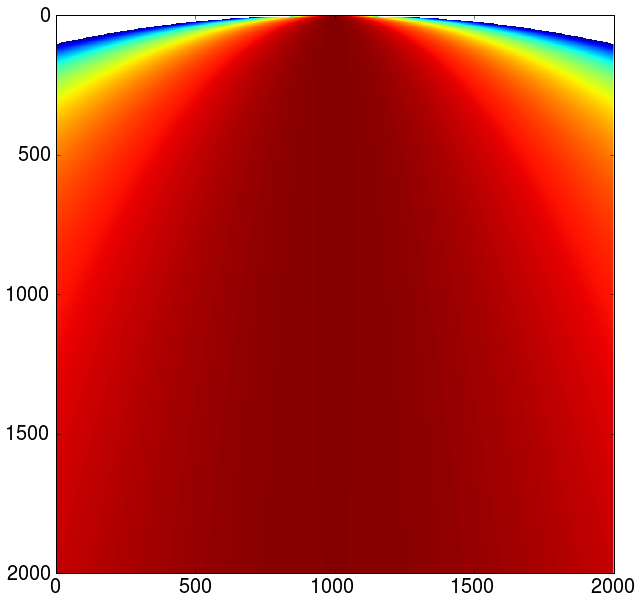

In [45]:
matplotlib.rcParams.update({"figure.figsize": (20,10)})
imshow(log10(grids[:,5000-1000:5000+1000]), interpolation='none', aspect=1, origin='upper')

        #imshow(P[t,0:100].T, interpolation='none', aspect=1, origin='lower'); #, extent=[1.5,4.5,3.5,6.5], vmin=300, vmax=600)
        #imshow(P[np.logspace(0,int(log10(T.shape[0])),1000).astype(int),:].T, interpolation='none', aspect=1, origin='lower'); #, extent=[1.5,4.5,3.5,6.5], vmin=300, vmax=600)
        #cb=colorbar(label="Time (s)"); cb.set_ticks(np.arange(300,601,100)); cb.ax.set_aspect(10)
        #axhline(x0,c='r')
        #xlabel("Cores per Executor"); xticks(numCoresToUse); ylabel("Executors"); yticks(numExecutorsToUse); title("Config: %d\nHDDs: %d"%(configuration,numHDD))
pass

### Compare the numeric and analytic concentration at different times.
The concentration as a fucntion of $x$ and $t$ is given by $c(x,t) = \frac{N}{\sqrt{4{\pi}Dt}} exp(-\frac{x^2}{4Dt})$, where $N=\int_{-\infty}^{\infty}c(x,t)dx$.

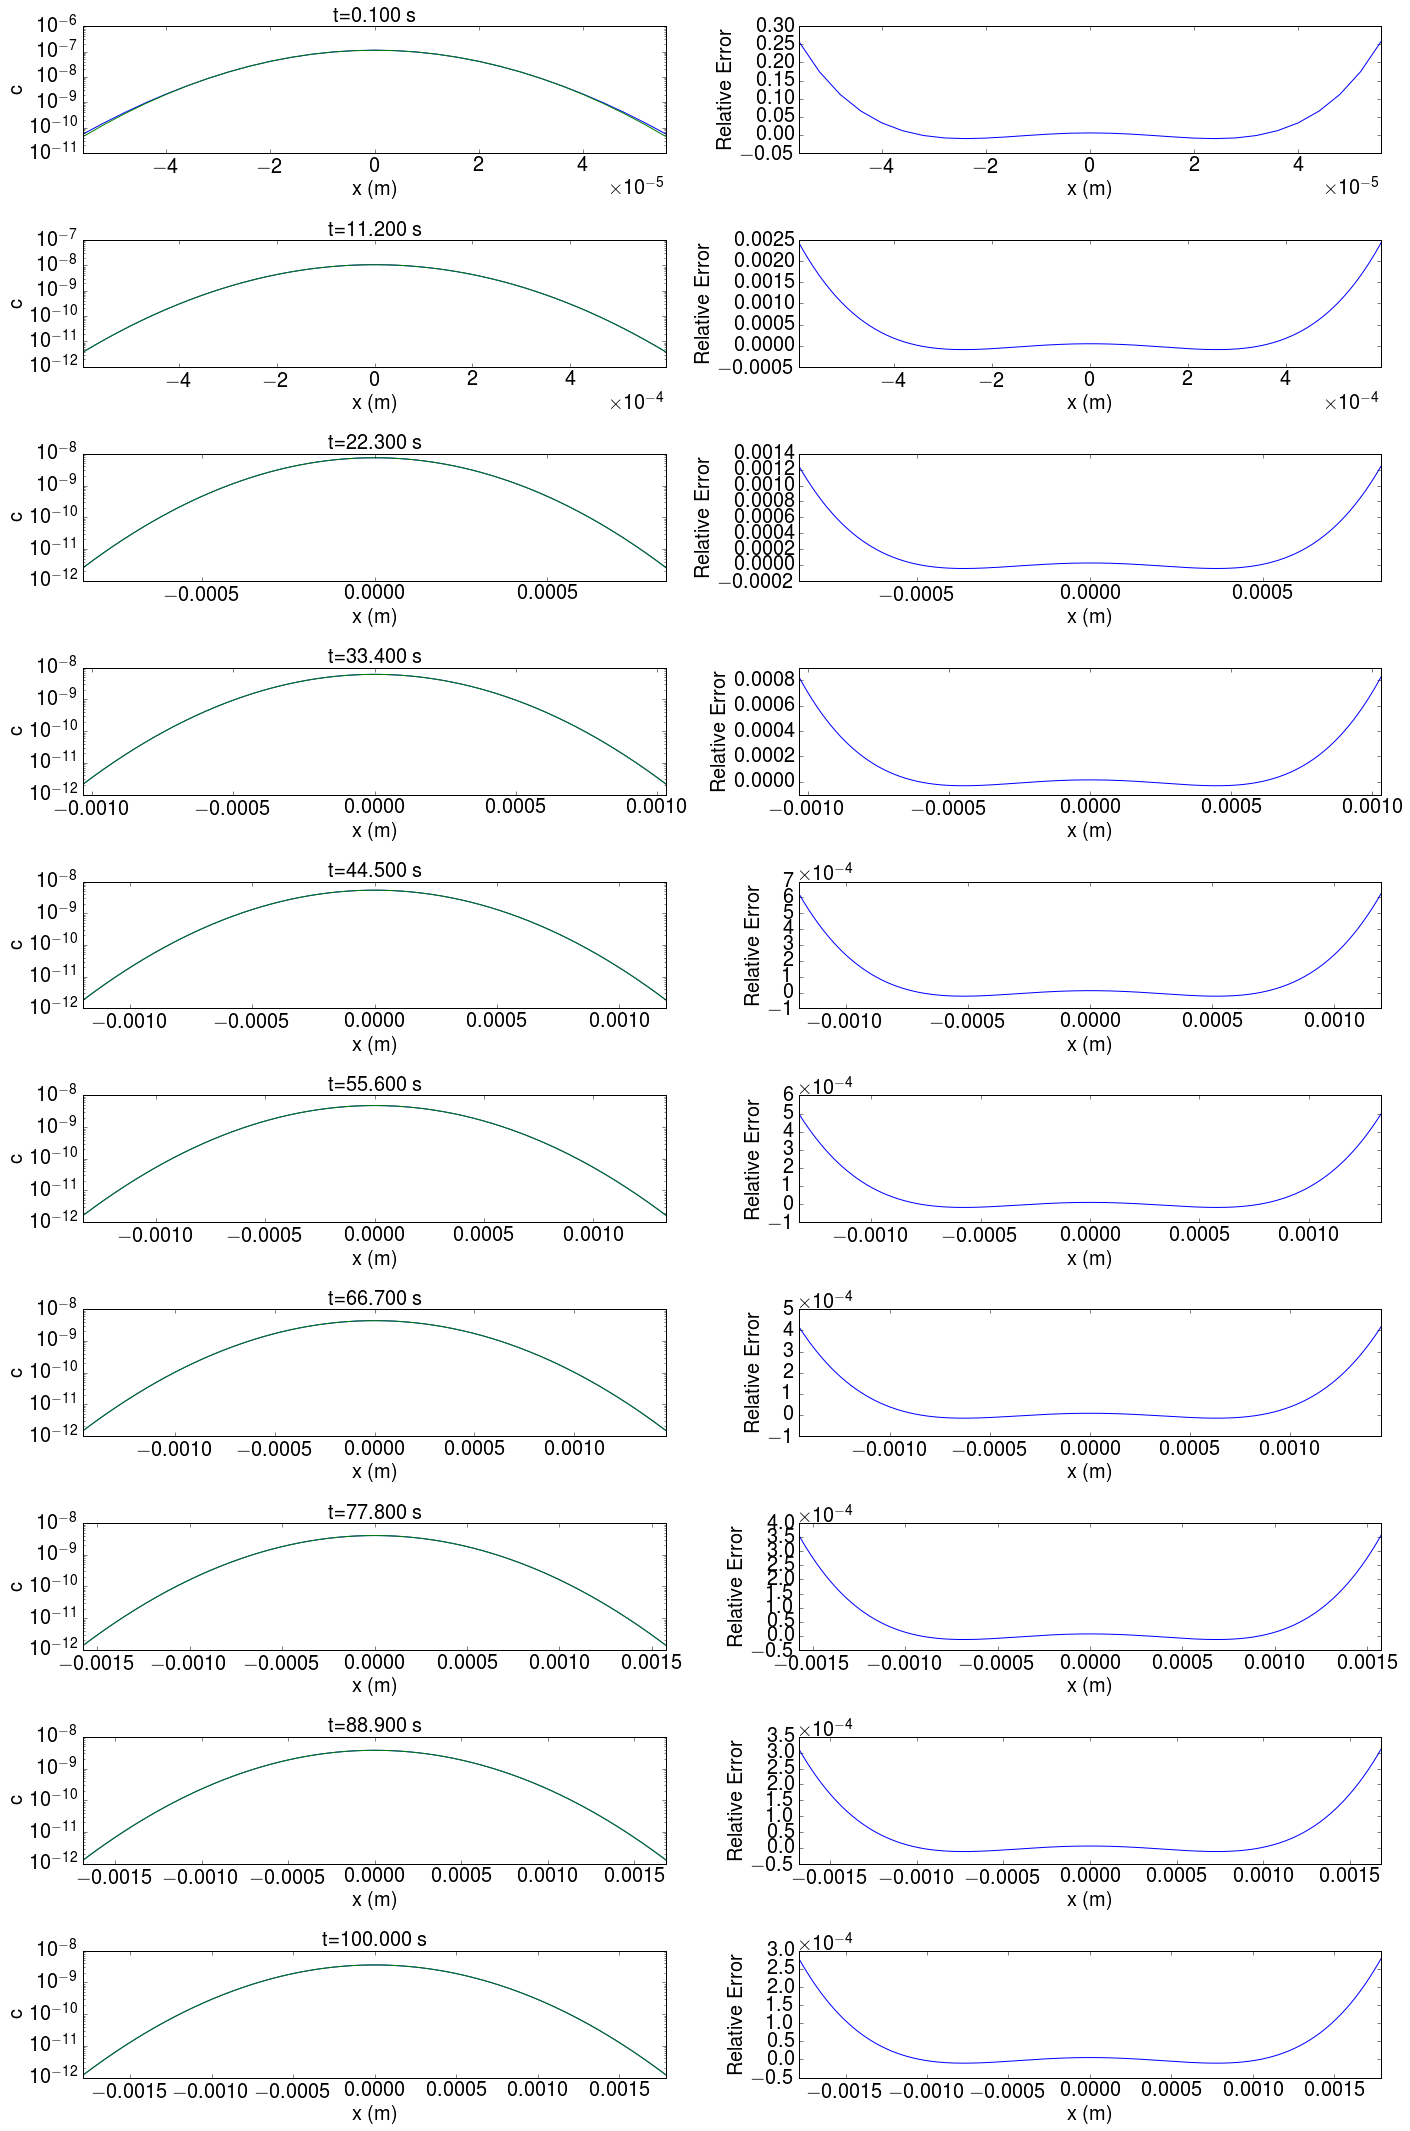

In [47]:
l=4e-6
N=1e-6*l
D=1000e-12
screen_style()
rows=10
cols=2
matplotlib.rcParams.update({"figure.figsize": (20,3*rows)})
plotIndex=1
for i in np.linspace(1,times.shape[0]-1,rows, dtype=int):
    t=times[i]
    xlimit=4*sqrt(2*D*t)/l
    xlimit=(int(ceil(grids.shape[1]/2-xlimit)),int(ceil(grids.shape[1]/2+xlimit)))
    x=(np.arange(0,grids.shape[1])-grids.shape[1]/2)*l
    x=x[xlimit[0]:xlimit[1]]
    c=grids[i,xlimit[0]:xlimit[1]]
    ctheory=(N/sqrt(4*pi*D*t))*exp(-((x**2)/(4*D*t)))
    subplot(rows,cols,plotIndex)
    plot(x, c)
    plot(x,ctheory)
    xlim([x[0],x[-1]]); xlabel(r"x (m)"); yscale("log"); ylabel("c"); title("t=%0.3f s"%t)
    plotIndex += 1
    subplot(rows,cols,plotIndex)
    err=(c-ctheory)/ctheory
    plot(x,err)
    xlim([x[0],x[-1]]); xlabel(r"x (m)"); ylabel("Relative Error");
    plotIndex += 1
plt.tight_layout()
pass

### Compare the variance as a function of time.
The variance as a function of time is given by $\sigma^2(t) = 2Dt$.

(2000,)
(2000,)


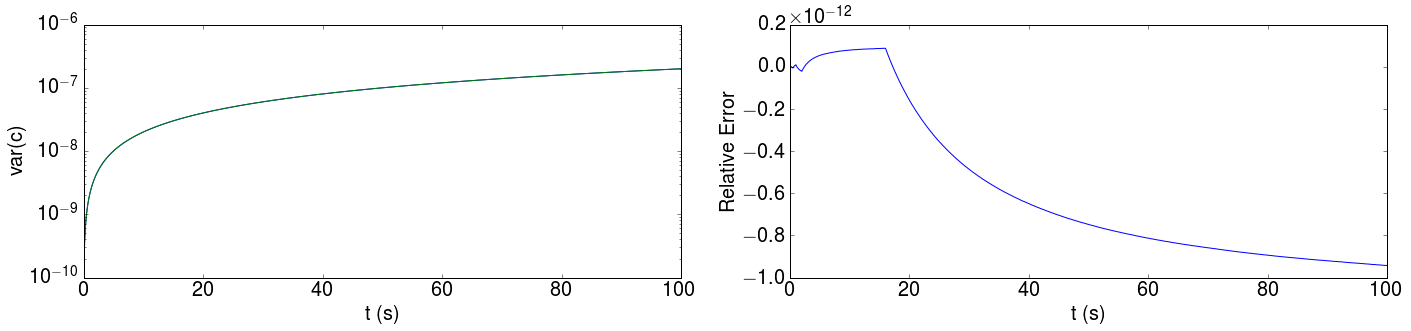

In [48]:
l=4e-6
D=1000e-12
screen_style()
matplotlib.rcParams.update({"figure.figsize": (20,5)})
subplot(1,2,1)
x=(np.arange(0,grids.shape[1])-grids.shape[1]/2)*l
t=times
varSim=np.zeros(times.shape)
for i in range(0,len(varSim)):
    c=grids[i,:]
    N=np.sum(c)
    varSim[i]=np.sum((x**2)*c/N)
print t.shape
print varSim.shape
varTheory=2*D*t
plot(t[1:],varSim[1:]);
plot(t[1:],varTheory[1:]);
xlabel("t (s)"); yscale("log"); ylabel("var(c)")
subplot(1,2,2)
err=(varSim-varTheory)/varTheory
plot(t,err)
xlabel("t (s)");  ylabel("Relative Error");
plt.tight_layout()
pass